# Reconnaissance et analyse automatique d'expressions faciales

**Fondamentaux du Deep Learning** - 2026-2027

**Binome :** Daniel Mon Watts ([@damonwatts11](https://github.com/damonwatts11)) - Alexandre Huet ([@SpectreAH](https://github.com/SpectreAH))  
**Formatrice :** Hanane Zerdoum 

---

## Plan du notebook

| Partie | Contenu | Statut |
|:------:|---------|--------|
| 0 | Configuration et imports | - |
| 1 | Recherche, comprehension et preparation des donnees | Obligatoire |
| 2 | Modele de reference (reseau dense) | Obligatoire |
| 3 | Construction d'un CNN avec Keras | Obligatoire |
| 4 | Entrainement du reseau | Obligatoire |
| 5 | Evaluation et analyse des erreurs | Obligatoire |
| 6 | Experimentation et amelioration (>= 3 experiences) | Obligatoire |
| 7 | Enrichissement avec les nouvelles notions | Enrichissement |
| 8 | Detection de plusieurs visages (YOLO) | Extension |
| 9 | Extension a la video | Extension (bonus) |


## 0 - Configuration et imports

Imports communs, graine aleatoire (reproductibilite) et constantes globales du projet.
Sur Google Colab, activez le GPU : *Execution -> Modifier le type d'execution -> GPU*.

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

#Constantes du projet (dataset : FERPlus)
#taille d'entree du reseau
IMG_SIZE    = (48, 48)
#1 = niveaux de gris, 3 = couleur
CHANNELS    = 1          
BATCH_SIZE  = 64
EPOCHS      = 30

#Les 8 classes de FERPlus
CLASS_NAMES = ['neutre', 'joie', 'surprise', 'tristesse', 'colere', 'degout', 'peur', 'mepris']
NUM_CLASSES = len(CLASS_NAMES)

## 1 - Recherche, comprehension et preparation des donnees

### 1.1 Choix du dataset : FERPlus (FER+)

Nous utilisons **FERPlus**. Ce dataset garde les images de **FER2013** et remplace les labels d'origine par de nouveaux labels, plus fiables.

- Dans FER2013, chaque image a **un seul label**, et ces labels contiennent des erreurs.
- Dans FERPlus, chaque image a ete annotee par **10 personnes**. Le fichier donne le nombre de votes pour chaque expression. Nous gardons l'expression qui a la **majorite des votes**.

FERPlus est donc compose de **deux fichiers** :

| | Images | Labels |
|---|---|---|
| Fichier | `fer2013.csv` | `fer2013new.csv` |
| Source | Competition Kaggle [Facial Expression Recognition Challenge](https://www.kaggle.com/c/challenges-in-representation-learning-facial-expression-recognition-challenge/data) | Depot GitHub [microsoft/FERPlus](https://github.com/microsoft/FERPlus) |
| Auteurs | Pierre-Luc Carrier et Aaron Courville. Article : Goodfellow et al., *Challenges in Representation Learning: A report on three machine learning contests*, 2013 | Barsoum, Zhang, Canton Ferrer et Zhang (Microsoft). Article : *Training Deep Networks for Facial Expression Recognition with Crowd-Sourced Label Distribution*, ICMI 2016 |
| Licence | Donnees diffusees par Kaggle pour la competition (conditions sur la page Kaggle) | MIT |

**Format des donnees**

- **35 887 images** de visages, de taille **48 x 48 pixels**, en **niveaux de gris** (1 seul canal), avec des pixels entre 0 et 255.
- Il n'y a pas de fichiers image (png, jpg). Chaque image est une **ligne du fichier CSV** : la colonne `pixels` contient les 48 x 48 = 2304 valeurs, separees par des espaces.
- La colonne `Usage` indique le role de chaque image : `Training`, `PublicTest` ou `PrivateTest`.
- Dans `fer2013new.csv`, il y a 10 colonnes de votes : les **8 expressions** (neutral, happiness, surprise, sadness, anger, disgust, fear, contempt) et 2 colonnes speciales, `unknown` (expression inconnue) et `NF` (*Not a Face* : l'image n'est pas un visage).
- Les deux fichiers ont le meme nombre de lignes, dans le meme ordre : la ligne *i* de `fer2013new.csv` donne les votes de l'image de la ligne *i* de `fer2013.csv`.

### 1.2 Chargement des deux fichiers

La page de la competition demande un compte Kaggle. Pour que le notebook s'execute de bout en bout, nous telechargeons une copie publique du meme fichier `fer2013.csv` avec `kagglehub`. Le fichier des labels vient directement du depot Microsoft.

In [ ]:
import glob
import shutil
import urllib.request

#images (pixels)
FER_CSV     = 'data/fer2013.csv'     
#labels FERPlus (votes des 10 annotateurs) 
FERPLUS_CSV = 'data/fer2013new.csv'   
FERPLUS_URL = 'https://raw.githubusercontent.com/microsoft/FERPlus/master/fer2013new.csv'

os.makedirs('data', exist_ok=True)

#Images: copie Kaggle de fer2013.csv
if not os.path.exists(FER_CSV):
    import kagglehub
    dossier = kagglehub.dataset_download('deadskull7/fer2013')
    fichier = glob.glob(os.path.join(dossier, '**', 'fer2013.csv'), recursive=True)[0]
    shutil.copy(fichier, FER_CSV)

#Labels: fichier officiel du depot Microsoft
if not os.path.exists(FERPLUS_CSV):
    urllib.request.urlretrieve(FERPLUS_URL, FERPLUS_CSV)

fer = pd.read_csv(FER_CSV)
ferplus = pd.read_csv(FERPLUS_CSV)

print('fer2013.csv    :', fer.shape, list(fer.columns))
print('fer2013new.csv :', ferplus.shape, list(ferplus.columns))

#Verification
assert len(fer) == len(ferplus) == 35887
assert (fer['Usage'].values == ferplus['Usage'].values).all()
print('Les deux fichiers sont bien alignes.')

c:\Users\alexh\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


fer2013.csv    : (35887, 3) ['emotion', 'pixels', 'Usage']
fer2013new.csv : (35887, 12) ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']
Les deux fichiers sont bien alignes.


### 1.3 Construction des labels (vote majoritaire)

Nous appliquons la regle des auteurs de FERPlus (mode *majority*) :

1. un vote isole (une seule personne sur 10) est ignore ;
2. on garde l'image seulement si une expression a **plus de 50 % des votes restants** ;
3. on retire l'image si le gagnant est `unknown` ou `NF`.

Les images sans majorite claire sont retirees : meme les humains ne sont pas d'accord sur leur expression.

In [ ]:
VOTE_COLS = ['neutral', 'happiness', 'surprise', 'sadness', 'anger',
             'disgust', 'fear', 'contempt', 'unknown', 'NF']

votes = ferplus[VOTE_COLS].values.astype('float32')    # (35887, 10)

#1) un vote isole est ignore
votes[votes <= 1] = 0

#2) une expression doit avoir plus de 50 % des votes restants
total    = votes.sum(axis=1)
gagnant  = votes.argmax(axis=1)                 # indice de la colonne gagnante
majorite = votes.max(axis=1) > 0.5 * total

#3) le gagnant doit etre une des 8 expressions (pas 'unknown' ni 'NF')
garder = majorite & (gagnant < NUM_CLASSES)

print('Images au depart      :', len(ferplus))
print('Sans majorite claire  :', (~majorite).sum())
print('Majorite unknown / NF :', (majorite & (gagnant >= NUM_CLASSES)).sum())
print('Images gardees        :', garder.sum())

Images au depart      : 35887
Sans majorite claire  : 4200
Majorite unknown / NF : 275
Images gardees        : 31412


In [ ]:
#On le transforme en image 48 x 48
X = np.array([np.array(p.split(), dtype='uint8') for p in fer['pixels']])
X = X.reshape(-1, *IMG_SIZE, CHANNELS)          # (35887, 48, 48, 1)

#On garde seulement les images qui ont un label valide
X     = X[garder]
#label entier entre 0 et 7
y     = gagnant[garder]     
#Training / PublicTest / PrivateTest                    
usage = ferplus['Usage'].values[garder]

print('X :', X.shape, X.dtype, '| min =', X.min(), '| max =', X.max())
print('y :', y.shape, '| classes :', np.unique(y))

X : (31412, 48, 48, 1) uint8 | min = 0 | max = 255
y : (31412,) | classes : [0 1 2 3 4 5 6 7]


### 1.4 Nombre d'images par classe

           train  validation  test  total      %
neutre      8740        1182  1090  11012  35.06
joie        7287         865   893   9045  28.79
surprise    3149         415   396   3960  12.61
tristesse   3014         351   384   3749  11.93
colere      2100         287   273   2660   8.47
degout       119          24    18    161   0.51
peur         532          62    83    677   2.16
mepris       119          13    16    148   0.47

train         25060
validation     3199
test           3153
total         31412
dtype: int64


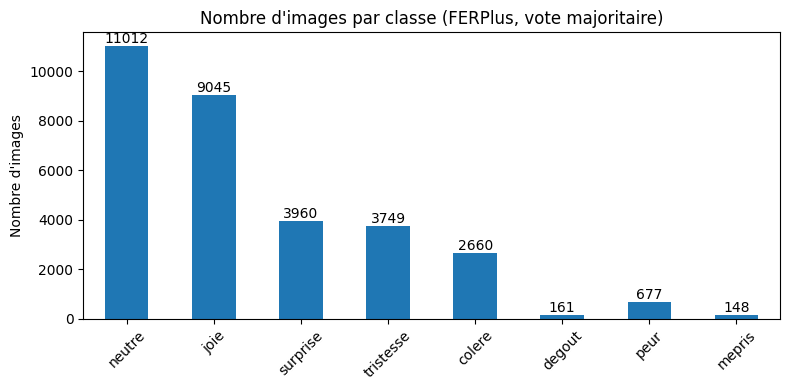

In [ ]:
counts = pd.crosstab(y, usage)[['Training', 'PublicTest', 'PrivateTest']]
counts.index = CLASS_NAMES
counts.columns = ['train', 'validation', 'test']
counts['total'] = counts.sum(axis=1)
counts['%'] = (100 * counts['total'] / counts['total'].sum()).round(2)

print(counts)
print()
print(counts[['train', 'validation', 'test', 'total']].sum())

ax = counts['total'].plot(kind='bar', figsize=(8, 4))
ax.bar_label(ax.containers[0])
plt.title("Nombre d'images par classe (FERPlus, vote majoritaire)")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.5 Exemples d'images pour chaque classe

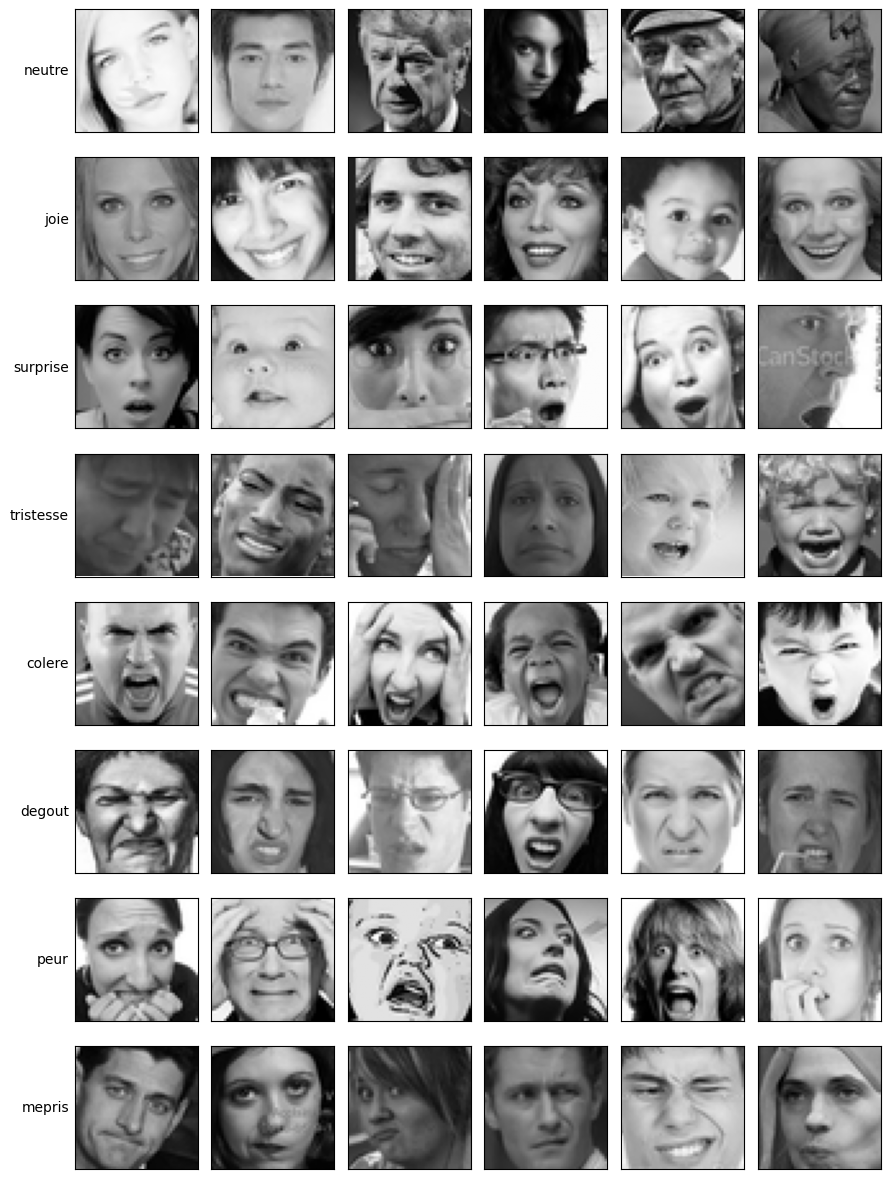

In [ ]:
N_EX = 6
rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(NUM_CLASSES, N_EX, figsize=(1.5 * N_EX, 1.5 * NUM_CLASSES))
for i, cls in enumerate(CLASS_NAMES):
    idx = rng.choice(np.where(y == i)[0], size=N_EX, replace=False)
    for j, k in enumerate(idx):
        axes[i, j].imshow(X[k].squeeze(), cmap='gray', vmin=0, vmax=255)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
    axes[i, 0].set_ylabel(cls, rotation=0, ha='right', va='center')
plt.tight_layout()
plt.show()

### 1.6 Bilan du dataset

Apres le vote majoritaire, il reste **31 412 images** sur 35 887 (4 475 images retirees : 4 200 sans majorite claire et 275 classees `unknown` ou `NF`).

| Classe | train | validation | test | total | % |
|---|---:|---:|---:|---:|---:|
| neutre | 8 740 | 1 182 | 1 090 | 11 012 | 35,06 |
| joie | 7 287 | 865 | 893 | 9 045 | 28,79 |
| surprise | 3 149 | 415 | 396 | 3 960 | 12,61 |
| tristesse | 3 014 | 351 | 384 | 3 749 | 11,93 |
| colere | 2 100 | 287 | 273 | 2 660 | 8,47 |
| degout | 119 | 24 | 18 | 161 | 0,51 |
| peur | 532 | 62 | 83 | 677 | 2,16 |
| mepris | 119 | 13 | 16 | 148 | 0,47 |
| **Total** | **25 060** | **3 199** | **3 153** | **31 412** | **100** |

**Desequilibre entre les classes.** Le dataset est tres desequilibre :

- `neutre` et `joie` representent a elles deux environ **64 %** des images ;
- `degout` et `mepris` ont chacune environ **0,5 %** des images (161 et 148 images) ;
- il y a environ **74 fois plus** d'images `neutre` que d'images `mepris`.

**Consequences pour la suite.**

- L'accuracy seule peut tromper : un modele qui repond toujours `neutre` aurait deja environ 35 % d'accuracy sur le test (1 090 / 3 153), sans rien reconnaitre.
- Les classes rares (`degout`, `mepris`, `peur`) seront plus difficiles a apprendre. Il faudra regarder les resultats **classe par classe** (partie 5) et tester des solutions (partie 6).

### 1.7 Preparation des donnees

| Etape | Ce que nous faisons | Role |
|---|---|---|
| Redimensionnement | Aucun : toutes les images font deja 48 x 48 | L'entree du reseau a une taille fixe `(48, 48, 1)`. Les visages detectes dans la partie 8 devront etre ramenes a cette taille. |
| Normalisation | Division des pixels par 255 | Les pixels passent de [0, 255] a [0, 1]. Des entrees petites et sur la meme echelle rendent la descente de gradient plus stable et plus rapide. |
| Labels | Vote majoritaire (partie 1.3) | Chaque image recoit un entier entre 0 et 7. |
| Encodage | One-hot avec `to_categorical` | La sortie du reseau est un vecteur de 8 probabilites (Softmax). Le label doit avoir la meme forme pour calculer la `categorical_crossentropy`. Exemple : 2 devient `[0, 0, 1, 0, 0, 0, 0, 0]`. |
| Train / validation / test | Decoupage officiel de la colonne `Usage` | `Training` -> train, `PublicTest` -> validation, `PrivateTest` -> test. |

**Pourquoi le decoupage officiel ?** C'est celui des auteurs de FER2013 et de FERPlus, donc nos resultats restent comparables. Chaque image est dans un seul ensemble.

- **train** : les images sur lesquelles le modele apprend ;
- **validation** : sert a suivre l'apprentissage et a comparer les modeles ;
- **test** : reserve a l'evaluation finale. Il ne sert jamais pendant l'entrainement ni pour choisir un modele.

In [ ]:
#Normalisation
X = X.astype('float32') / 255.0

#Encodage one-hot des labels
y_cat = keras.utils.to_categorical(y, NUM_CLASSES)
print('Exemple de label :', y[0], '(' + CLASS_NAMES[y[0]] + ') ->', y_cat[0])

#Decoupage officiel train / validation / test
is_train = usage == 'Training'
is_val   = usage == 'PublicTest'
is_test  = usage == 'PrivateTest'

X_train, y_train = X[is_train], y_cat[is_train]
X_val,   y_val   = X[is_val],   y_cat[is_val]
X_test,  y_test  = X[is_test],  y_cat[is_test]

print('train      :', X_train.shape, y_train.shape)
print('validation :', X_val.shape, y_val.shape)
print('test       :', X_test.shape, y_test.shape)
print('pixels     : min =', X_train.min(), '| max =', X_train.max())

Exemple de label : 0 (neutre) -> [1. 0. 0. 0. 0. 0. 0. 0.]
train      : (25060, 48, 48, 1) (25060, 8)
validation : (3199, 48, 48, 1) (3199, 8)
test       : (3153, 48, 48, 1) (3153, 8)
pixels     : min = 0.0 | max = 1.0


## 2 - Modele de reference (reseau dense)

Avant le CNN, nous construisons un reseau simple qui sert de **point de comparaison** :

`Image (48 x 48 x 1) -> Flatten (2304) -> Dense 256 + ReLU -> Dense 8 + Softmax`

| Notion | Dans notre modele |
|---|---|
| Image -> entree du reseau | `Flatten` deroule l'image 48 x 48 en un vecteur de 2304 valeurs (pixels entre 0 et 1). |
| Poids et biais | Chaque neurone calcule z = w1 x1 + ... + wn xn + b. Les poids w et les biais b sont les parametres appris. La couche Dense 256 a 2304 x 256 + 256 = 590 080 parametres. |
| Propagation avant | Les donnees traversent les couches une par une : Z = WX + b, puis A = g(Z), jusqu'a la sortie. |
| Fonction d'activation | **ReLU** dans la couche cachee : max(0, z). Sans activation non lineaire, plusieurs couches equivalent a une seule couche lineaire. |
| Sortie multiclasse | 8 neurones + **Softmax** : 8 probabilites positives dont la somme vaut 1. La classe predite est celle qui a la plus grande probabilite. |
| Fonction de perte | **categorical_crossentropy** : -log de la probabilite donnee a la bonne classe. C'est la log-loss generalisee a 8 classes. |
| Retropropagation | On calcule le gradient de la perte par rapport a chaque poids, de la sortie vers l'entree (regle de la chaine). |
| Descente de gradient | On corrige les poids dans le sens oppose au gradient : W <- W - alpha x dW. Nous utilisons **Adam**, une version amelioree qui adapte le pas pour chaque poids. |

In [ ]:
def build_baseline():
    model = keras.Sequential([
        keras.Input(shape=(*IMG_SIZE, CHANNELS)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='baseline_dense')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline = build_baseline()
baseline.summary()

Model: "baseline_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,136 (2.26 MB)

 Trainable params: 592,136 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = baseline.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=15, batch_size=BATCH_SIZE)

base_loss, base_acc = baseline.evaluate(X_test, y_test, verbose=0)
print('Reseau dense - accuracy test :', round(base_acc, 4))

Epoch 1/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4107 - loss: 1.5823 - val_accuracy: 0.4817 - val_loss: 1.4517
Epoch 2/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4732 - loss: 1.4407 - val_accuracy: 0.5161 - val_loss: 1.4049
Epoch 3/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4855 - loss: 1.4132 - val_accuracy: 0.5183 - val_loss: 1.3915
Epoch 4/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4947 - loss: 1.3910 - val_accuracy: 0.5180 - val_loss: 1.3794
Epoch 5/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4994 - loss: 1.3744 - val_accuracy: 0.5148 - val_loss: 1.3634
Epoch 6/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5035 - loss: 1.3593 - val_accuracy: 0.5289 - val_loss: 1.3480
Epoch 7/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5129 - loss: 1.3383 - val_accuracy: 0.5320 - val_loss: 1.3328
Epoch 8/15
392/392 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5206 - loss: 1.3177 - val_accuracy: 0.

**Resultat du reseau dense :** accuracy test de **50,6 %** (environ 51 a 53 % en validation, 54,7 % en entrainement apres 15 epoques).

- C'est mieux que le hasard (12,5 % pour 8 classes) et qu'un modele qui repond toujours `neutre` (34,6 %), mais cela reste faible.
- `Flatten` detruit la structure spatiale de l'image : le reseau ne sait pas quels pixels sont voisins. Un sourire decale de quelques pixels devient une entree completement differente.
- Ce modele a 592 136 parametres, presque autant que notre CNN (684 552). La difference de resultat viendra donc de l'**architecture**, pas du nombre de parametres.

## 3 - Construction d'un CNN avec Keras

### Notre architecture

`Image -> [Conv2D + BatchNorm + MaxPooling] x 3 -> Flatten -> Dense 128 + Dropout -> Dense 8 + Softmax`

**Pourquoi ce choix ?**

- **3 blocs** : chaque MaxPooling divise la taille par 2 (48 -> 24 -> 12 -> 6). Apres 3 blocs, les feature maps font 6 x 6 : assez petit pour la partie Dense, assez grand pour garder l'information.
- **32 -> 64 -> 128 filtres** : on double le nombre de filtres quand la taille diminue. Les premiers filtres detectent des motifs simples (bords, traits), les suivants combinent ces motifs (yeux, bouche, sourcils).
- **Noyaux 3 x 3** : petite fenetre, peu de parametres, et suffisante pour des motifs locaux sur une image de 48 x 48.
- **BatchNormalization** : normalise les sorties de chaque couche, ce qui rend l'entrainement plus stable et plus rapide.
- **Dropout 0,5** : pendant l'entrainement, la moitie des neurones de la couche Dense est desactivee au hasard. Cela limite le surapprentissage.

### Les notions

| Notion | Explication |
|---|---|
| Filtre | Petite matrice de poids (ici 3 x 3) apprise par le reseau. Chaque filtre detecte un motif. |
| Convolution | Le filtre glisse sur l'image ; a chaque position, on fait la somme des pixels multiplies par les poids du filtre. |
| Feature map | Image de sortie d'un filtre : elle montre ou le motif est present. 32 filtres donnent 32 feature maps. |
| Taille du kernel | Taille du filtre : 3 x 3 ici. |
| Stride | Pas de deplacement du filtre. Ici stride = 1 (valeur par defaut). |
| Padding | `same` : on ajoute des zeros autour de l'image pour que la sortie garde la meme taille (48 x 48 reste 48 x 48). |
| ReLU | max(0, z) : garde les valeurs positives, met les negatives a 0. Non lineaire et rapide. |
| Pooling | MaxPooling 2 x 2 : garde la valeur maximale de chaque zone 2 x 2. Divise la taille par 2 et rend le modele moins sensible aux petits decalages. |
| Flatten | Deroule le volume 6 x 6 x 128 en un vecteur de 4608 valeurs pour les couches Dense. |
| Dense | Couche ou chaque neurone est relie a toutes les sorties de la couche precedente. Elle combine les motifs detectes. |
| Couche de sortie | Dense 8 + Softmax : une probabilite par expression. |

In [ ]:
def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(*IMG_SIZE, CHANNELS)),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ], name='cnn')
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn = build_cnn()
cnn.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,552 (2.61 MB)

 Trainable params: 684,104 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

### Dimensions et parametres couche par couche

| Couche | Sortie | Parametres | Calcul |
|---|---|---:|---|
| Entree | 48 x 48 x 1 | 0 | |
| Conv2D 32, 3 x 3, same | 48 x 48 x 32 | 320 | (3 x 3 x 1 + 1) x 32 |
| BatchNorm | 48 x 48 x 32 | 128 | 4 x 32 |
| MaxPooling 2 x 2 | 24 x 24 x 32 | 0 | |
| Conv2D 64, 3 x 3, same | 24 x 24 x 64 | 18 496 | (3 x 3 x 32 + 1) x 64 |
| BatchNorm | 24 x 24 x 64 | 256 | 4 x 64 |
| MaxPooling 2 x 2 | 12 x 12 x 64 | 0 | |
| Conv2D 128, 3 x 3, same | 12 x 12 x 128 | 73 856 | (3 x 3 x 64 + 1) x 128 |
| BatchNorm | 12 x 12 x 128 | 512 | 4 x 128 |
| MaxPooling 2 x 2 | 6 x 6 x 128 | 0 | |
| Flatten | 4608 | 0 | 6 x 6 x 128 |
| Dense 128 + ReLU | 128 | 589 952 | (4608 + 1) x 128 |
| Dropout 0,5 | 128 | 0 | |
| Dense 8 + Softmax | 8 | 1 032 | (128 + 1) x 8 |
| **Total** | | **684 552** | dont 448 non entrainables (moyennes et variances de BatchNorm) |

- Les 3 couches de convolution n'ont que 92 672 parametres, car un filtre est **partage** sur toute l'image.
- La couche Dense 128 contient a elle seule environ **86 %** des parametres.

## 4 - Entrainement du reseau

| Choix | Valeur | Justification |
|---|---|---|
| Fonction de perte | `categorical_crossentropy` | Classification a 8 classes, sortie Softmax et labels en one-hot. |
| Optimiseur | Adam (learning rate 0,001) | Descente de gradient amelioree : le pas s'adapte pour chaque poids. Valeur par defaut, efficace sans reglage. |
| Batch size | 64 | 25 060 / 64 = 392 mises a jour par epoque. Bon compromis entre stabilite du gradient, vitesse et memoire sur CPU. |
| Nombre d'epoques | 30 maximum | Avec **EarlyStopping** (patience 8) : l'entrainement s'arrete quand la perte de validation ne s'ameliore plus pendant 8 epoques, et on garde les meilleurs poids. **ReduceLROnPlateau** divise le learning rate par 2 apres 4 epoques sans amelioration. |
| Metrique | accuracy | Facile a lire pendant l'entrainement. Comme les classes sont desequilibrees, nous regardons aussi le F1 par classe et le F1 macro (parties 5 et 6). |

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5),
]

history = cnn.fit(X_train, y_train,
                   validation_data=(X_val, y_val),
                   epochs=EPOCHS, batch_size=BATCH_SIZE,
                   callbacks=callbacks)

Epoch 1/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4509 - loss: 1.5622 - val_accuracy: 0.4955 - val_loss: 1.4036 - learning_rate: 0.0010
Epoch 2/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5645 - loss: 1.2416 - val_accuracy: 0.6443 - val_loss: 1.0196 - learning_rate: 0.0010
Epoch 3/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6063 - loss: 1.1101 - val_accuracy: 0.6624 - val_loss: 1.0102 - learning_rate: 0.0010
Epoch 4/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6397 - loss: 1.0162 - val_accuracy: 0.6696 - val_loss: 0.9932 - learning_rate: 0.0010
Epoch 5/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6674 - loss: 0.9365 - val_accuracy: 0.6308 - val_loss: 1.0659 - learning_rate: 0.0010
Epoch 6/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6889 - loss: 0.8730 - val_accuracy: 0.6358 - val_loss: 1.1076 - learning_rate: 0.0010
Epoch 7/30
392/392 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7170 - loss: 0.

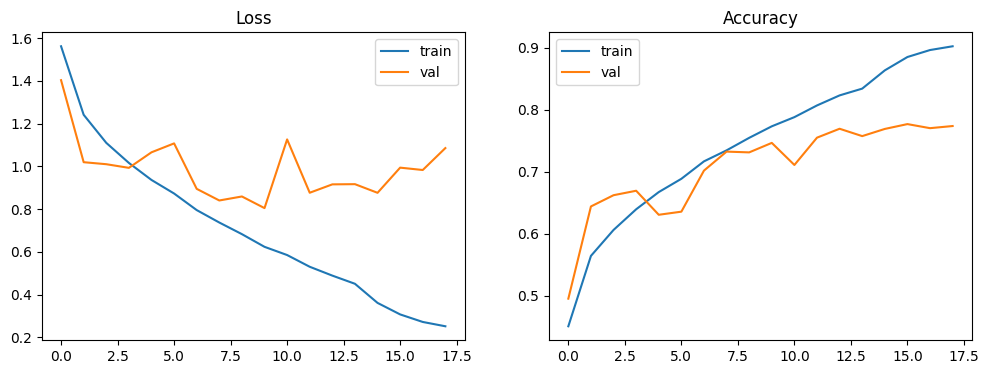

In [ ]:
def plot_history(history):
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h['loss'], label='train'); ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].legend()
    ax[1].plot(h['accuracy'], label='train'); ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title('Accuracy'); ax[1].legend()
    plt.show()

plot_history(history)

### Interpretation des courbes

- L'entrainement a dure **18 epoques** (environ 7 s par epoque sur CPU). La meilleure epoque est la **10** : perte de validation 0,80 et accuracy de validation 74,7 %. L'EarlyStopping a garde ces poids.
- Apres l'epoque 10, la perte d'entrainement continue de baisser (0,62 -> 0,25) et l'accuracy d'entrainement monte jusqu'a **90 %**, alors que la perte de validation remonte (0,80 -> 1,09) et que l'accuracy de validation reste autour de **77 %**.
- C'est du **surapprentissage** : le modele apprend par coeur les images d'entrainement au lieu de generaliser.
- La courbe de validation est aussi irreguliere (par exemple un pic de perte a 1,13 a l'epoque 11). Le learning rate a ete divise par 2 a l'epoque 15.
- Ces observations nous donnent les pistes de la partie 6 : data augmentation contre le surapprentissage, learning rate plus petit contre l'instabilite.

## 5 - Evaluation et analyse des erreurs

L'accuracy seule ne suffit pas (classes desequilibrees). Produisez une **matrice de confusion** et analysez : expressions bien reconnues, souvent confondues, les plus difficiles. Affichez des exemples `image + vraie classe + classe predite + probabilite`, dont plusieurs **erreurs**.

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7263 - loss: 0.8566
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

      neutre       0.68      0.88      0.77      1090
        joie       0.78      0.88      0.83       893
    surprise       0.78      0.80      0.79       396
   tristesse       0.59      0.24      0.34       384
      colere       0.76      0.45      0.57       273
      degout       0.00      0.00      0.00        18
        peur       0.92      0.14      0.25        83
      mepris       0.00      0.00      0.00        16

    accuracy                           0.73      3153
   macro avg       0.56      0.42      0.44      3153
weighted avg       0.72      0.73      0.70      3153



c:\Users\alexh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alexh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alexh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

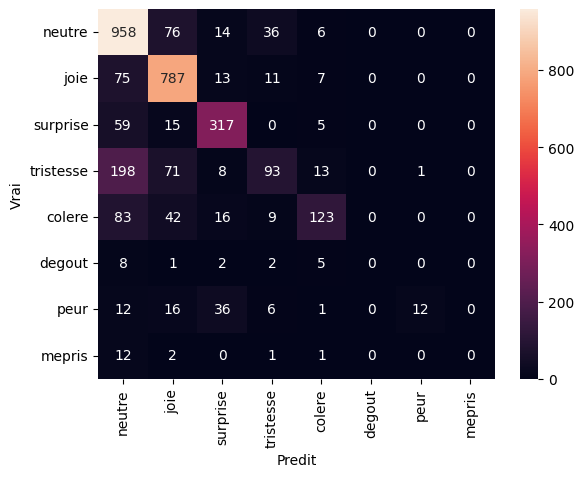

In [ ]:
#Evaluation sur le test
test_loss, test_acc = cnn.evaluate(X_test, y_test)
y_pred = cnn.predict(X_test)
y_pred_cls = y_pred.argmax(1); y_true_cls = y_test.argmax(1)

print(classification_report(y_true_cls, y_pred_cls, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true_cls, y_pred_cls)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predit'); plt.ylabel('Vrai'); plt.show()

In [ ]:
# --- Exemples : image + vraie classe + classe predite + probabilite ---
proba = y_pred.max(1)
bons = np.where(y_pred_cls == y_true_cls)[0]
erreurs = np.where(y_pred_cls != y_true_cls)[0]
rng = np.random.default_rng(SEED)


def afficher_exemples(indices, titre):
    fig, axes = plt.subplots(1, len(indices), figsize=(2.3 * len(indices), 3))
    for ax, k in zip(axes, indices):
        ax.imshow(X_test[k].squeeze(), cmap='gray', vmin=0, vmax=1)
        couleur = 'green' if y_pred_cls[k] == y_true_cls[k] else 'red'
        ax.set_title(f'Vrai : {CLASS_NAMES[y_true_cls[k]]}\nPredit : {CLASS_NAMES[y_pred_cls[k]]}\n({proba[k]:.2f})',
                     fontsize=9, color=couleur)
        ax.axis('off')
    plt.tight_layout()
    fig.suptitle(titre, y=1.03)
    plt.show()


afficher_exemples(rng.choice(bons, 6, replace=False), 'Predictions correctes')
afficher_exemples(rng.choice(erreurs, 6, replace=False), 'Predictions incorrectes')

# Erreurs les plus "sures" : le modele se trompe avec une forte probabilite
pires = erreurs[np.argsort(proba[erreurs])[::-1][:6]]
afficher_exemples(pires, 'Erreurs avec la plus forte probabilite')

### Analyse des resultats du CNN de reference (test)

**Resultat global :** accuracy test **72,6 %** (contre 50,6 % pour le reseau dense), mais **F1 macro de 0,44** seulement. L'accuracy cache de grosses differences entre les classes.

| Classe | Recall | F1 | Commentaire |
|---|---:|---:|---|
| neutre | 0,88 | 0,77 | Bien reconnue, mais le modele predit trop souvent `neutre` |
| joie | 0,88 | 0,83 | La mieux reconnue : le sourire est un signe tres visible |
| surprise | 0,80 | 0,79 | Bien reconnue : yeux et bouche grands ouverts |
| tristesse | 0,24 | 0,34 | 198 images sur 384 (52 %) sont predites `neutre` |
| colere | 0,45 | 0,57 | 83 images sur 273 predites `neutre` |
| peur | 0,14 | 0,25 | 36 images sur 83 (43 %) predites `surprise` |
| degout | 0 | 0 | Jamais predit |
| mepris | 0 | 0 | Jamais predit (12 images sur 16 predites `neutre`) |

**Expressions les plus confondues**

- **tristesse -> neutre** : une tristesse legere ressemble beaucoup a un visage neutre.
- **peur -> surprise** : dans les deux cas, les yeux sont grands ouverts et la bouche est ouverte.
- **colere et mepris -> neutre** : le modele choisit la classe majoritaire quand il hesite.

**Pourquoi certaines classes sont difficiles ?**

- **Tres peu d'exemples** : seulement 119 images d'entrainement pour `degout` et pour `mepris`, contre 8 740 pour `neutre`. Le modele n'a presque jamais vu ces expressions.
- **Expressions subtiles** : le mepris (un seul coin de la bouche releve) se voit a peine sur une image de 48 x 48.
- **Ressemblances entre expressions** : meme les 10 annotateurs de FERPlus n'etaient pas toujours d'accord.

**Analyse des predictions incorrectes (images ci-dessus).** Les erreurs correspondent surtout aux confusions de la matrice : expressions faibles predites `neutre`, peur predite `surprise`. Les erreurs avec une forte probabilite concernent souvent des images ambigues (visage tourne, main devant le visage, faible luminosite), ou meme un humain hesiterait.

## 6 - Experimentation et amelioration

### 6.1 Plan des experiences

Nous partons du **CNN de reference** (parties 3 et 4) et nous changeons **une seule chose a la fois**, pour savoir ce qui cause chaque effet. Chaque experience repond a un probleme observe dans nos resultats :

| # | Modification | Probleme observe | Ce que nous attendons |
|:-:|---|---|---|
| 0 | CNN de reference | - | Point de comparaison |
| 1 | **Data augmentation** (miroir horizontal, rotation, zoom) | Surapprentissage apres l'epoque 10 (train 90 %, validation 77 %) | Moins d'ecart entre train et validation |
| 2 | **Poids des classes** (`class_weight='balanced'`) | `degout` et `mepris` ne sont jamais predits (F1 = 0) | Meilleur F1 sur les classes rares |
| 3 | **Learning rate divise par 10** (0,001 -> 0,0001) | La perte de validation est instable d'une epoque a l'autre | Un apprentissage plus regulier |

**Regles de comparaison**

- Tous les modeles sont compares sur le jeu de **validation**. Le jeu de test sert une seule fois, pour le modele final.
- Memes reglages pour tous : batch 64, 30 epoques maximum, EarlyStopping (patience 8) et ReduceLROnPlateau.
- Critere principal : le **F1 macro** sur la validation. C'est la moyenne du F1 des 8 classes : chaque classe compte autant, meme les classes rares. L'accuracy seule favorise `neutre` et `joie`, qui representent 64 % des images.

In [ ]:
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight


def build_cnn_exp(augmentation=False, lr=1e-3):
    #Meme architecture que le CNN de reference avec 2 options
    couches = [keras.Input(shape=(*IMG_SIZE, CHANNELS))]
    if augmentation:
        couches += [layers.RandomFlip('horizontal'),
                    layers.RandomRotation(0.1),
                    layers.RandomZoom(0.1)]
    couches += [
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ]
    model = keras.Sequential(couches)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def resultats_val(nom, model, epoque):
    #Accuracy et F1 macro sur la validation
    y_val_pred = model.predict(X_val, verbose=0).argmax(1)
    y_val_true = y_val.argmax(1)
    acc = np.mean(y_val_pred == y_val_true)
    f1 = f1_score(y_val_true, y_val_pred, average='macro', zero_division=0)
    print(f'{nom:<26} | val accuracy = {acc:.4f} | val F1 macro = {f1:.4f}')
    return {'Experience': nom, 'Val accuracy': round(acc, 4),
            'Val F1 macro': round(f1, 4), 'Meilleure epoque': epoque}


#Poids des classes: une erreur sur une classe rare compte plus dans la perte
y_train_int = y_train.argmax(1)
poids = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_int)
CLASS_WEIGHT = dict(enumerate(poids))
print('Poids des classes :', {CLASS_NAMES[k]: round(v, 2) for k, v in CLASS_WEIGHT.items()})
print()

EXPERIENCES = {
    '1 - Data augmentation': dict(augmentation=True),
    '2 - Poids des classes': dict(class_weight=CLASS_WEIGHT),
    '3 - Learning rate 1e-4': dict(lr=1e-4),
}

#Experience 0: le CNN deja entraine en partie 4 (meilleurs poids gardes par EarlyStopping)
resultats = [resultats_val('0 - CNN de reference', cnn,
                           int(np.argmin(history.history['val_loss'])) + 1)]
modeles = {'0 - CNN de reference': cnn}
historiques = {'0 - CNN de reference': history}

for nom, params in EXPERIENCES.items():
    keras.utils.set_random_seed(SEED)
    model = build_cnn_exp(augmentation=params.get('augmentation', False),
                          lr=params.get('lr', 1e-3))
    h = model.fit(X_train, y_train,
                  validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH_SIZE,
                  class_weight=params.get('class_weight'),
                  callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True),
                             keras.callbacks.ReduceLROnPlateau(patience=4, factor=0.5)],
                  verbose=0)
    modeles[nom] = model
    historiques[nom] = h
    resultats.append(resultats_val(nom, model, int(np.argmin(h.history['val_loss'])) + 1))

tableau = pd.DataFrame(resultats)
print()
print(tableau.to_string(index=False))

Poids des classes : {'neutre': np.float64(0.36), 'joie': np.float64(0.43), 'surprise': np.float64(0.99), 'tristesse': np.float64(1.04), 'colere': np.float64(1.49), 'degout': np.float64(26.32), 'peur': np.float64(5.89), 'mepris': np.float64(26.32)}

0 - CNN de reference       | val accuracy = 0.7468 | val F1 macro = 0.4629
1 - Data augmentation      | val accuracy = 0.7709 | val F1 macro = 0.4927
2 - Poids des classes      | val accuracy = 0.3501 | val F1 macro = 0.0900
3 - Learning rate 1e-4     | val accuracy = 0.7496 | val F1 macro = 0.5861

            Experience  Val accuracy  Val F1 macro  Meilleure epoque
  0 - CNN de reference        0.7468        0.4629                10
 1 - Data augmentation        0.7709        0.4927                27
 2 - Poids des classes        0.3501        0.0900                 1
3 - Learning rate 1e-4        0.7496        0.5861                16


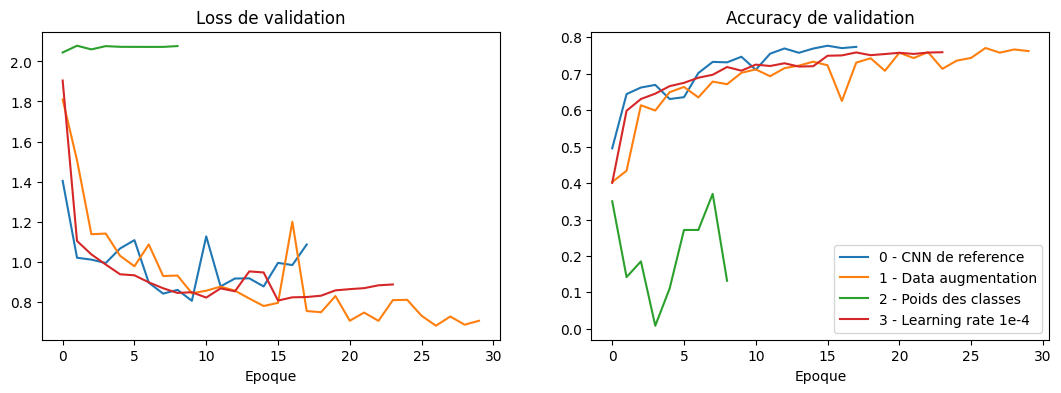

In [ ]:
#Courbes de validation des 4 modeles
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for nom, h in historiques.items():
    ax[0].plot(h.history['val_loss'], label=nom)
    ax[1].plot(h.history['val_accuracy'], label=nom)
ax[0].set_title('Loss de validation'); ax[0].set_xlabel('Epoque')
ax[1].set_title('Accuracy de validation'); ax[1].set_xlabel('Epoque')
ax[1].legend()
plt.show()

### 6.2 Choix du modele final

Nous gardons le modele qui a le meilleur **F1 macro sur la validation**. Ensuite, et seulement ensuite, nous l'evaluons une seule fois sur le jeu de test. Le modele choisi devient `cnn`, qui est utilise dans la demonstration (partie 8).

Modele final : 3 - Learning rate 1e-4
Accuracy test : 0.7333
F1 macro test : 0.5736

              precision    recall  f1-score   support

      neutre       0.72      0.82      0.77      1090
        joie       0.79      0.83      0.81       893
    surprise       0.79      0.77      0.78       396
   tristesse       0.57      0.49      0.53       384
      colere       0.68      0.59      0.63       273
      degout       1.00      0.22      0.36        18
        peur       0.88      0.25      0.39        83
      mepris       1.00      0.19      0.32        16

    accuracy                           0.73      3153
   macro avg       0.80      0.52      0.57      3153
weighted avg       0.73      0.73      0.72      3153



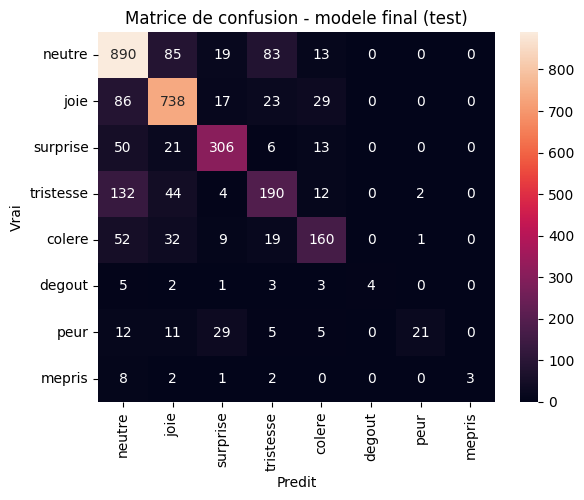

In [ ]:
meilleur = tableau.loc[tableau['Val F1 macro'].idxmax(), 'Experience']
print('Modele final :', meilleur)

cnn = modeles[meilleur]

#Evaluation finale sur le test (une seule fois)
test_loss, test_acc = cnn.evaluate(X_test, y_test, verbose=0)
y_test_pred = cnn.predict(X_test, verbose=0).argmax(1)
y_test_true = y_test.argmax(1)
print('Accuracy test :', round(test_acc, 4))
print('F1 macro test :', round(f1_score(y_test_true, y_test_pred, average='macro', zero_division=0), 4))
print()
print(classification_report(y_test_true, y_test_pred, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matrice de confusion - modele final (test)')
plt.xlabel('Predit'); plt.ylabel('Vrai'); plt.show()

### 6.3 Analyse des experiences

| # | Modification | Val. accuracy | Val. F1 macro | Meilleure epoque | Observations |
|:-:|---|:-:|:-:|:-:|---|
| 0 | CNN de reference | 74,7 % | 0,463 | 10 | Surapprentissage rapide ; `degout` et `mepris` jamais predits |
| 1 | Data augmentation | **77,1 %** | 0,493 | 27 | Meilleure accuracy et perte de validation la plus basse (environ 0,7). Apprentissage plus lent : le modele progressait encore a 30 epoques |
| 2 | Poids des classes | 35,0 % | 0,090 | 1 | Echec : l'entrainement ne converge pas (perte de validation bloquee vers 2,05), arret apres 9 epoques |
| 3 | Learning rate 1e-4 | 75,0 % | **0,586** | 16 | Meilleur F1 macro ; courbes plus regulieres ; commence a reconnaitre les classes rares |

- **Data augmentation** : en montrant des images retournees, tournees et zoomees, le modele voit plus de variete et apprend moins par coeur. La perte de validation descend plus bas que celle du CNN de reference et l'accuracy gagne 2,4 points. En contrepartie, l'apprentissage est plus lent.
- **Poids des classes** : avec `class_weight='balanced'`, une erreur sur `degout` ou `mepris` compte **26 fois** plus qu'une erreur moyenne, contre 0,36 pour `neutre`. Ces poids sont trop extremes : les gradients deviennent tres grands et instables, et le modele n'apprend rien d'utile. Il faudrait des poids plus doux (par exemple la racine carree) ou un learning rate plus petit.
- **Learning rate 1e-4** : des pas plus petits donnent un apprentissage plus regulier. L'accuracy est proche de la reference (+0,3 point), mais le F1 macro gagne **12 points** (0,463 -> 0,586) : le modele reconnait enfin une partie des classes rares.

**Modele final retenu : 3 - Learning rate 1e-4**, parce qu'il a le meilleur F1 macro en validation. Avec nos classes desequilibrees, c'est le critere le plus juste : il donne le meme poids a chaque expression.

**Resultat sur le test (evalue une seule fois) :**

| | CNN de reference | Modele final (LR 1e-4) |
|---|:-:|:-:|
| Accuracy test | 72,6 % | **73,3 %** |
| F1 macro test | 0,44 | **0,57** |
| Recall tristesse | 0,24 | 0,49 |
| Recall peur | 0,14 | 0,25 |
| Recall degout | 0 | 0,22 |
| Recall mepris | 0 | 0,19 |

Le test confirme le choix fait sur la validation. Quand le modele final predit `degout` ou `mepris`, il a toujours raison (precision de 1,0), mais il les predit encore rarement. La confusion **peur -> surprise** reste la plus frequente pour la peur (29 images sur 83).

**Piste suivante** : combiner la data augmentation (meilleure accuracy) et le learning rate 1e-4 (meilleur F1 macro), avec plus d'epoques.

## 7 - Enrichissement avec les nouvelles notions

| Notion du cours | Ou dans le projet | Effet |
|---|---|---|
| **Data augmentation** | Partie 6, experience 1 | Meilleure accuracy de validation (77,1 %) et moins de surapprentissage |
| **Regularisation** | Dropout 0,5 et BatchNormalization dans le CNN (partie 3), EarlyStopping et ReduceLROnPlateau (partie 4) | Limite le surapprentissage et garde les meilleurs poids |
| **Modele pre-entraine** | YOLOv8 entraine sur des visages (partie 8) | Detection des visages sans avoir a entrainer un detecteur |
| **Detection d'objets / YOLO** | Parties 8 et 9 | Passage d'un visage deja extrait a une image ou une video avec plusieurs personnes |

**Transfer Learning (non realise, piste pour la suite).** Un reseau comme MobileNetV2 est pre-entraine sur ImageNet avec des images **en couleur (3 canaux)** et plus grandes (au moins 96 x 96 pour les poids fournis). Nos images font 48 x 48 en niveaux de gris : il faudrait les agrandir et copier le canal gris 3 fois. Le modele est aussi beaucoup plus lourd a entrainer, et nous n'avons qu'un CPU (pas de GPU sous Windows avec TensorFlow). Ce serait la prochaine amelioration a tester, car les premieres couches d'un reseau pre-entraine savent deja detecter des bords et des textures.

## 8 - Extension : detection de plusieurs visages (YOLO)

`Image -> detection des visages -> bounding boxes -> extraction -> meme pretraitement -> CNN -> expression + probabilite`

### Les notions

| Notion | Explication |
|---|---|
| Classification vs detection | La **classification** donne une seule reponse pour toute l'image. La **detection** localise chaque objet : une boite, une classe et un score pour chaque visage. |
| Bounding box | Rectangle autour d'un visage, donne par ses coins (x1, y1) et (x2, y2). |
| Confidence score | Probabilite donnee par YOLO qu'il y ait bien un visage dans la boite. Nous gardons les boites avec un score > 0,5. |
| IoU | *Intersection over Union* : aire commune de deux boites divisee par l'aire de leur union. Mesure si deux boites se chevauchent (0 = pas du tout, 1 = identiques). |
| NMS | *Non-Maximum Suppression* : si plusieurs boites se chevauchent beaucoup (IoU eleve) sur le meme visage, on garde seulement celle qui a le meilleur score. YOLO le fait automatiquement. |
| Principe de YOLO | *You Only Look Once* : le reseau regarde l'image **une seule fois** et predit en meme temps toutes les boites et leurs scores. C'est pour cela qu'il est rapide. |
| Modele pre-entraine | Nous utilisons `yolov8n-face`, deja entraine a detecter des visages ([akanametov/yolo-face](https://github.com/akanametov/yolo-face), licence GPL-3.0). Nous ne l'avons pas re-entraine. |
| Precision, recall, mAP | **Precision** : part des boites predites qui sont vraiment des visages. **Recall** : part des vrais visages trouves. **mAP** : moyenne de la precision sur tous les niveaux de recall (aire sous la courbe precision-recall). Nous ne les avons pas mesures, car nos images de test n'ont pas de boites de reference. |

**Choix du detecteur.** Un YOLO standard (entraine sur COCO) detecte des *personnes*, pas des *visages*. Nous utilisons donc un YOLO entraine specialement sur des visages.

**Coherence du pretraitement.** La fonction `prep` applique a chaque visage detecte exactement le meme traitement que les images d'entrainement : niveaux de gris, redimensionnement en 48 x 48, division par 255, forme `(1, 48, 48, 1)`.

In [21]:
pip install ultralytics

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

#Modele de detection de visages (YOLOv8 entraine sur des visages pas sur COCO)
FACE_WEIGHTS = 'models/yolov8n-face.pt'
FACE_URL = 'https://github.com/akanametov/yolo-face/releases/download/1.0.0/yolov8n-face.pt'

os.makedirs('models', exist_ok=True)
if not os.path.exists(FACE_WEIGHTS):
    urllib.request.urlretrieve(FACE_URL, FACE_WEIGHTS)

detector = YOLO(FACE_WEIGHTS)


def prep(visage):
    #MEME pretraitement que l'entrainement
    gris = cv2.cvtColor(visage, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, IMG_SIZE, interpolation=cv2.INTER_AREA)
    gris = gris.astype('float32') / 255.0
    return gris.reshape(1, *IMG_SIZE, CHANNELS)


def analyser_image(img, conf_min=0.5, verbose=True):
    #image couleur au format OpenCV (BGR)
    sortie = img.copy()
    h, w = img.shape[:2]
    results = detector(img, conf=conf_min, verbose=False)

    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        #garde la box a l'interieur de l'image
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, w), min(y2, h)
        visage = img[y1:y2, x1:x2]
        if visage.size == 0:
            continue

        #plus rapide que predict pour 1 image
        pred = cnn(prep(visage), training=False).numpy()[0]   
        classe = CLASS_NAMES[pred.argmax()]
        score = pred.max()
        conf_visage = float(box.conf[0])

        #dessiner la box + expression + probabilite
        texte = f'{classe} {score:.2f}'
        cv2.rectangle(sortie, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(sortie, texte, (x1, max(y1 - 8, 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        if verbose:
            print(f'Visage ({x1}, {y1}, {x2}, {y2}) | detection {conf_visage:.2f} | {classe} {score:.2f}')

    return sortie

Image : C:\Users\alexh\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\assets\zidane.jpg
Visage (913, 92, 1055, 276) | detection 0.82 | tristesse 0.70
Visage (542, 242, 663, 448) | detection 0.77 | colere 0.88


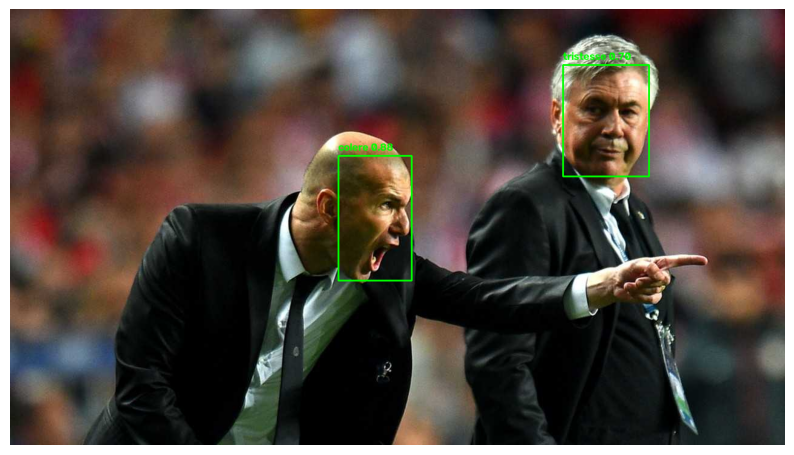

In [ ]:
from ultralytics.utils import ASSETS
#chemin de mon image
IMAGE_PATH = 'demo/groupe.jpg'          
if not os.path.exists(IMAGE_PATH):
#image d'exemple fournie avec ultralytics
    IMAGE_PATH = str(ASSETS / 'zidane.jpg')   
print('Image :', IMAGE_PATH)

img = cv2.imread(IMAGE_PATH)
assert img is not None, 'Image introuvable : verifier le chemin'

resultat = analyser_image(img)

plt.figure(figsize=(10, 7))
#OpenCV = BGR, matplotlib = RGB
plt.imshow(cv2.cvtColor(resultat, cv2.COLOR_BGR2RGB))   
plt.axis('off')
plt.show()

**Resultat sur l'image de test (2 personnes) :**

- Les **2 visages** sont detectes, avec des scores de 0,82 et 0,77.
- Le visage de gauche (bouche grande ouverte, en train de crier) est classe **colere avec une probabilite de 0,88** : la prediction est coherente.
- Le visage de droite (expression calme et serieuse) est classe **tristesse (0,70)**. On retrouve la confusion **tristesse / neutre** observee dans la partie 5.

## 9 - Extension a la video (bonus)

`Video -> images successives -> detection -> extraction des visages -> CNN -> predictions -> affichage`

Une video est une suite d'images. Nous appliquons la fonction `analyser_image` de la partie 8 a **chaque image** de la video, puis nous enregistrons la video annotee (`video_annotee.mp4`, dans le meme dossier que la video).

La webcam n'a pas pu etre ouverte sur notre ordinateur (OpenCV ne trouvait aucune camera disponible) : nous utilisons donc une video enregistree. Le code essaie quand meme la webcam si aucune video n'est trouvee.

Video trouvee : C:\Users\alexh/Desktop/demo\video.mp4
295 images traitees en 6.3 s (46.8 images par seconde)
Video annotee : C:\Users\alexh/Desktop/demo\video_annotee.mp4


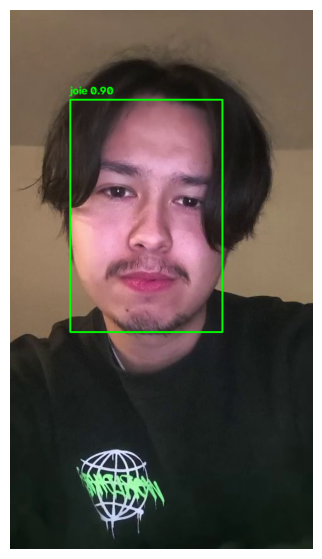

In [ ]:
import time
import glob

#Recherche automatique de la video dans un dossier 'demo'
DOSSIERS = ['demo',
            os.path.expanduser('~/Desktop/demo'),
#Bureau Windows synchronise avec OneDrive
            os.path.expanduser('~/OneDrive/Desktop/demo')]   

videos = []
for d in DOSSIERS:
    for ext in ('*.mp4', '*.mov', '*.avi', '*.mkv'):
        videos += glob.glob(os.path.join(d, ext))
videos = [v for v in dict.fromkeys(videos) if 'annotee' not in os.path.basename(v)]

if videos:
    VIDEO_PATH = videos[0]
    SORTIE_PATH = os.path.join(os.path.dirname(VIDEO_PATH), 'video_annotee.mp4')
    print('Video trouvee :', VIDEO_PATH)
else:
    VIDEO_PATH = 'demo/video.mp4'
    SORTIE_PATH = 'demo/video_annotee.mp4'
    print('Aucune video trouvee dans :', DOSSIERS)


def ouvrir_source(source):
    #Fichier video : ouverture normale
    if isinstance(source, str):
        return cv2.VideoCapture(source)
    #Webcam : on essaie plusieurs pilotes Windows et plusieurs numeros de camera
    for index in (source, 1):
        for pilote in (cv2.CAP_DSHOW, cv2.CAP_MSMF, cv2.CAP_ANY):
            cap = cv2.VideoCapture(index, pilote)
            if cap.isOpened() and cap.read()[0]:
                print(f'Webcam ouverte (camera {index}, pilote {pilote})')
                return cap
            cap.release()
    return cv2.VideoCapture()   


def analyser_video(source, sortie=None, afficher=True):
    cap = ouvrir_source(source)
    assert cap.isOpened(), "Impossible d'ouvrir la video ou la webcam"
    fps = cap.get(cv2.CAP_PROP_FPS) or 25   

    writer = None
    derniere = None
    n = 0
    debut = time.time()

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        #meme traitement que pour une image: detection + CNN + dessin
        derniere = analyser_image(frame, verbose=False)
        n += 1

        if sortie:
            if writer is None:
                h, w = derniere.shape[:2]
                os.makedirs(os.path.dirname(sortie), exist_ok=True)
                writer = cv2.VideoWriter(sortie, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
            writer.write(derniere)

        if afficher:
            cv2.imshow('Expressions faciales (q pour quitter)', derniere)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break

    cap.release()
    if writer is not None:
        writer.release()
    if afficher:
        cv2.destroyAllWindows()

    duree = time.time() - debut
    print(f'{n} images traitees en {duree:.1f} s ({n / max(duree, 1e-6):.1f} images par seconde)')
    return derniere


if os.path.exists(VIDEO_PATH):
    derniere = analyser_video(VIDEO_PATH, sortie=SORTIE_PATH, afficher=False)
    print('Video annotee :', SORTIE_PATH)
else:
    print("Pas de video : webcam en direct (appuyer sur q dans la fenetre pour quitter)")
    derniere = analyser_video(0, afficher=True)

#derniere image annotee
if derniere is not None:
    plt.figure(figsize=(10, 7))
    plt.imshow(cv2.cvtColor(derniere, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

**Resultat :** **295 images** traitees en **6,3 s**, soit environ **47 images par seconde** sur CPU. C'est plus rapide que le temps reel (25 a 30 images par seconde), grace a deux modeles legers : YOLOv8n (version *nano*) et notre CNN de 684 552 parametres.

**Limites**

- Chaque image est analysee **independamment** : la prediction peut changer d'une image a l'autre, meme si l'expression ne change pas. On pourrait faire la moyenne des probabilites sur les dernieres images pour lisser le resultat.
- Le modele a ete entraine sur des images de 48 x 48 en niveaux de gris : un visage de profil, mal eclaire ou en partie cache sera moins bien reconnu.

## Conclusion

**Ce que nous avons realise**

- Preparation du dataset **FERPlus** : 31 412 images, 8 expressions, decoupage officiel train / validation / test, analyse du fort desequilibre entre les classes.
- Un **reseau dense** de reference : **50,6 %** d'accuracy sur le test.
- Un **CNN** a 3 blocs de convolution : **72,6 %** sur le test. La convolution apporte **+22 points** avec un nombre de parametres comparable.
- **3 experiences** : la data augmentation donne la meilleure accuracy de validation ; le learning rate 1e-4 donne le meilleur F1 macro ; les poids de classes trop forts empechent l'apprentissage.
- **Modele final** (learning rate 1e-4) : **73,3 %** d'accuracy et **0,57** de F1 macro sur le test (contre 0,44 pour le CNN de reference).
- Une application complete : **detection de plusieurs visages avec YOLO** et analyse d'une **video** a environ 47 images par seconde.

**Limites**

- Les classes rares (`degout`, `mepris`, `peur`) restent mal reconnues : trop peu d'exemples.
- Confusions entre expressions proches : tristesse / neutre, peur / surprise.
- Images petites (48 x 48) et en niveaux de gris.

**Pistes d'amelioration**

- Combiner data augmentation et learning rate 1e-4, avec plus d'epoques.
- Des poids de classes plus doux pour aider les classes rares sans bloquer l'apprentissage.
- Le Transfer Learning avec un reseau pre-entraine.
- Lisser les predictions dans le temps pour la video.

`Neurone -> MLP -> Backpropagation -> Keras -> CNN -> Convolution -> Classification multiclasse -> Softmax -> Amelioration -> Detection -> YOLO -> Application complete de vision par ordinateur`